In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

TRAIN_DIR = Path("../data/raw/GTSRB/Final_Training/Images")
TEST_DIR = Path("../data/raw/GTSRB/Final_Test/Images")
TEST_LABELS = Path("../data/raw/GT-final_test.csv")

print("Train directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())
print("Test labels file exists:", TEST_LABELS.exists())

Train directory exists: True
Test directory exists: True
Test labels file exists: True


In [6]:
train_images = list(TRAIN_DIR.rglob("*.ppm"))
test_images = list(TEST_DIR.rglob("*.ppm"))

print("Training images:", len(train_images))
print("Test images:", len(test_images))

Training images: 39209
Test images: 12630


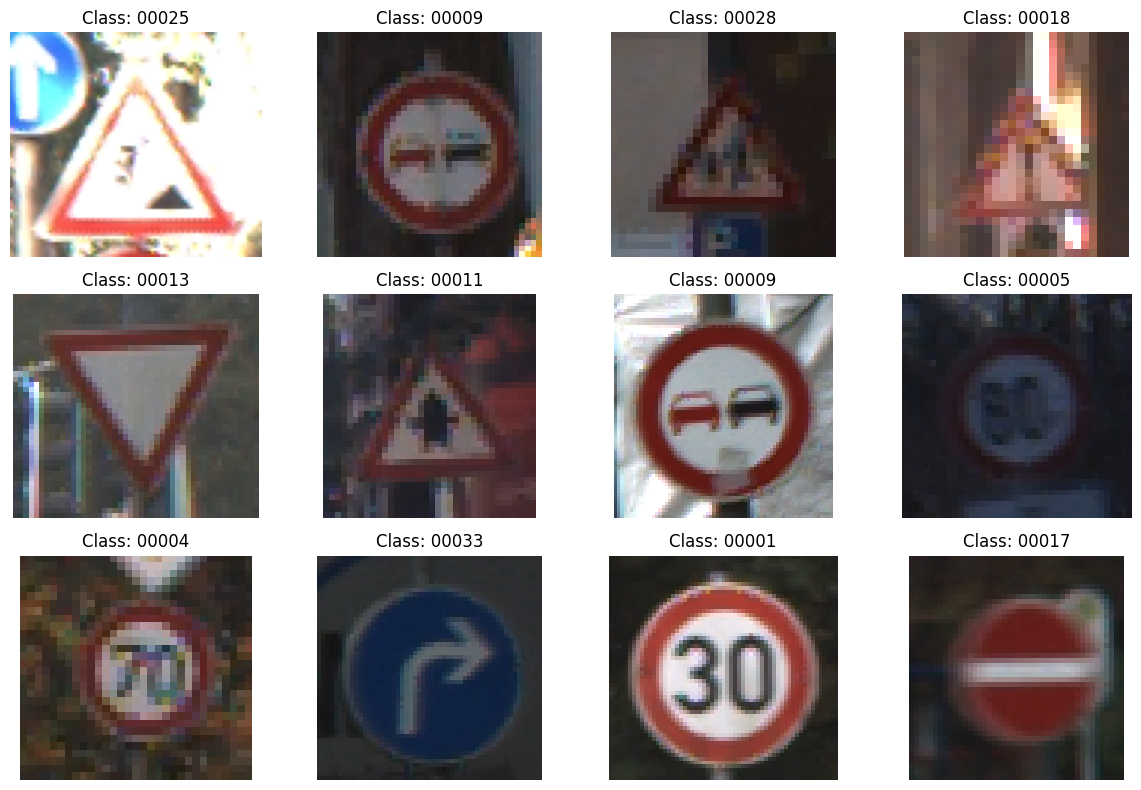

In [7]:
sample_images = random.sample(train_images, 12)

plt.figure(figsize=(12, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    label = img_path.parent.name

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
class_counts = {}

for class_dir in TRAIN_DIR.iterdir():
    if class_dir.is_dir():
        class_id = class_dir.name
        image_count = len(list(class_dir.glob("*.ppm")))
        class_counts[class_id] = image_count

class_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["class_id", "image_count"]
)

class_df = class_df.sort_values("class_id")

class_df.head()

,class_id,image_count
3,00000,210
8,00001,2220
26,00002,2250
25,00003,1410
24,00004,1980


In [9]:
print("Number of classes:", len(class_df))

Number of classes: 43


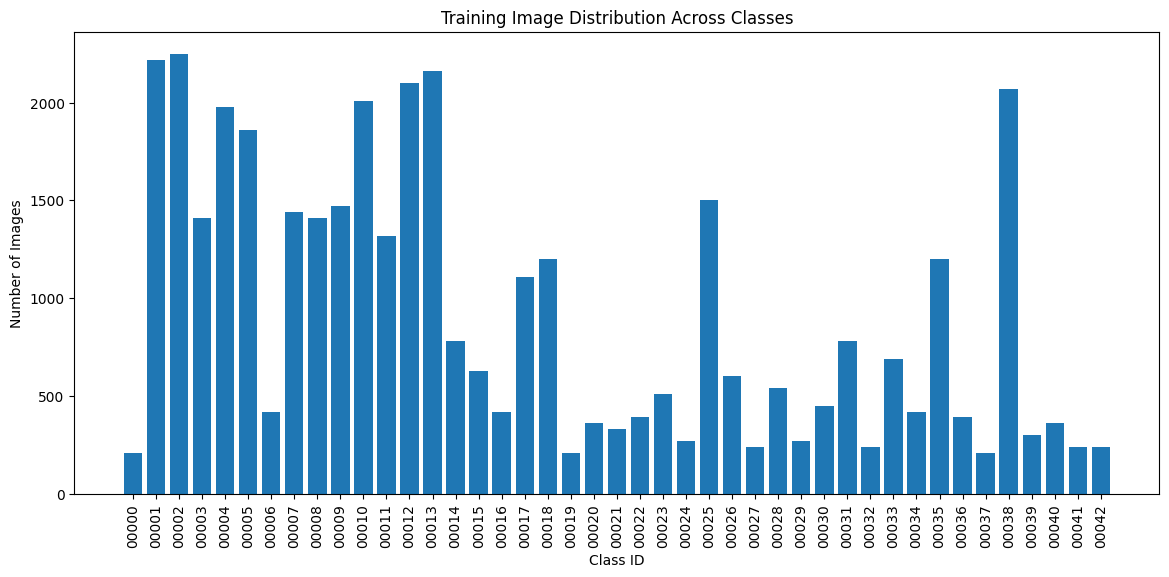

In [10]:
plt.figure(figsize=(14, 6))

plt.bar(class_df["class_id"], class_df["image_count"])

plt.xticks(rotation=90)
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Training Image Distribution Across Classes")

plt.show()

In [11]:
print("Minimum images in a class:", class_df["image_count"].min())
print("Maximum images in a class:", class_df["image_count"].max())
print("Average images per class:", round(class_df["image_count"].mean(), 2))

Minimum images in a class: 210
Maximum images in a class: 2250
Average images per class: 911.84


In [12]:
test_df = pd.read_csv(TEST_LABELS, sep=';')
test_df.head()

,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
0,00000.ppm,53,54,6,5,48,49,16
1,00001.ppm,42,45,5,5,36,40,1
2,00002.ppm,48,52,6,6,43,47,38
3,00003.ppm,27,29,5,5,22,24,33
4,00004.ppm,60,57,5,5,55,52,11


In [13]:
test_df = pd.read_csv(TEST_LABELS, sep=';')
test_df.head()

,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
0,00000.ppm,53,54,6,5,48,49,16
1,00001.ppm,42,45,5,5,36,40,1
2,00002.ppm,48,52,6,6,43,47,38
3,00003.ppm,27,29,5,5,22,24,33
4,00004.ppm,60,57,5,5,55,52,11


In [14]:
SIGN_LABELS = {
    0: "Speed limit (20km/h)",
    1: "Speed limit (30km/h)",
    2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)",
    4: "Speed limit (70km/h)",
    5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)",
    7: "Speed limit (100km/h)",
    8: "Speed limit (120km/h)",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing for vehicles over 3.5 tons"
}

In [15]:
print(SIGN_LABELS[14])
print(SIGN_LABELS[17])
print(SIGN_LABELS[33])

Stop
No entry
Turn right ahead


In [16]:
image_sizes = []

sample_subset = random.sample(train_images, 500)

for img_path in sample_subset:
    img = Image.open(img_path)
    image_sizes.append(img.size)

size_df = pd.DataFrame(image_sizes, columns=["width", "height"])

size_df.head()

,width,height
0,36,35
1,51,53
2,45,42
3,46,46
4,48,51


In [17]:
size_df.describe()

,width,height
count,500.000000,500.000000
mean,49.886000,49.610000
std,24.537996,23.363424
min,26.000000,25.000000
25%,35.000000,35.000000
50%,42.000000,42.000000
75%,57.000000,55.250000
max,180.000000,160.000000


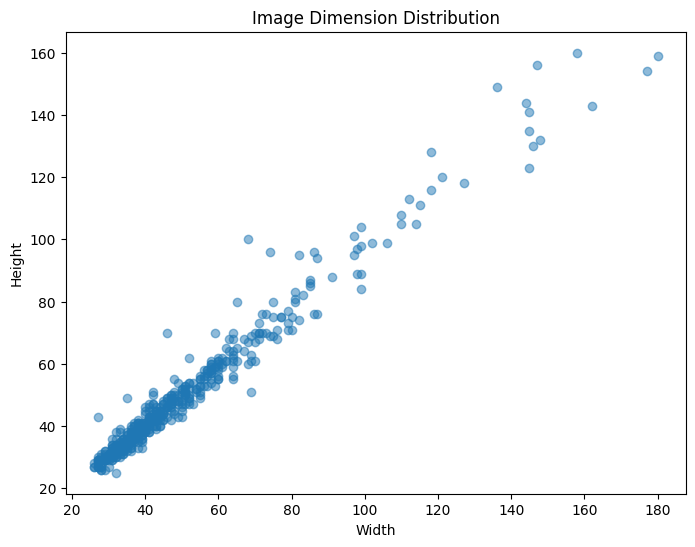

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(size_df["width"], size_df["height"], alpha=0.5)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Dimension Distribution")

plt.show()

In [19]:
import numpy as np
import cv2
from sklearn.model_selection import train_test_split

In [20]:
def load_training_data(train_dir, img_size=(64, 64)):
    images = []
    labels = []

    for class_dir in train_dir.iterdir():
        if not class_dir.is_dir():
            continue

        class_id = int(class_dir.name)

        for img_path in class_dir.glob("*.ppm"):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)

            images.append(img)
            labels.append(class_id)

    return np.array(images), np.array(labels)

In [21]:
X, y = load_training_data(TRAIN_DIR)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (39209, 64, 64, 3)
y shape: (39209,)


In [22]:
X = X.astype("float32") / 255.0

print(X.min(), X.max())

0.0 1.0


In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (31367, 64, 64, 3)
X_val: (7842, 64, 64, 3)
y_train: (31367,)
y_val: (7842,)


In [25]:
print(np.unique(y_train))
print("Total classes:", len(np.unique(y_train)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Total classes: 43


In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [27]:
num_classes = 43

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [28]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,747 (2.63 MB)

 Trainable params: 688,747 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 71s 72ms/step - accuracy: 0.7704 - loss: 0.8358 - val_accuracy: 0.9524 - val_loss: 0.1687
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 73s 74ms/step - accuracy: 0.9768 - loss: 0.0908 - val_accuracy: 0.9865 - val_loss: 0.0640
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 68s 70ms/step - accuracy: 0.9867 - loss: 0.0472 - val_accuracy: 0.9774 - val_loss: 0.0810
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 68s 69ms/step - accuracy: 0.9920 - loss: 0.0291 - val_accuracy: 0.9848 - val_loss: 0.0577
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 79s 81ms/step - accuracy: 0.9914 - loss: 0.0281 - val_accuracy: 0.9802 - val_loss: 0.0868
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 78s 79ms/step - accuracy: 0.9940 - loss: 0.0190 - val_accuracy: 0.9779 - val_loss: 0.1106
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 77s 79ms/step - accuracy: 0.9942 - loss: 0.0200 - val_accuracy: 0.9920 - val_loss: 0.0427
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 74s 75ms/step - accuracy: 0.9969 - loss: 0.0118 - 

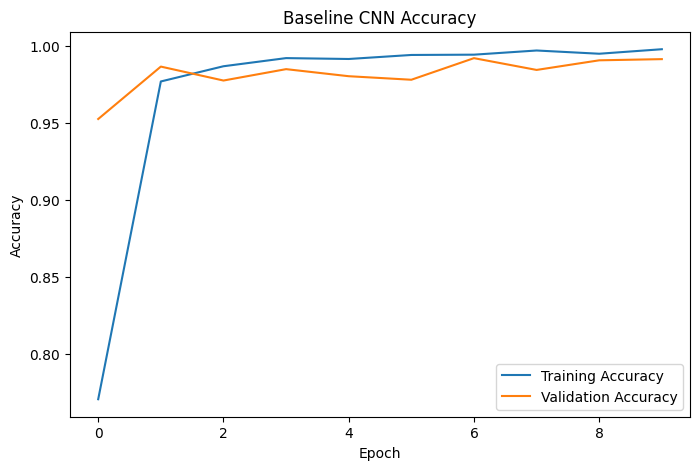

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()
plt.show()

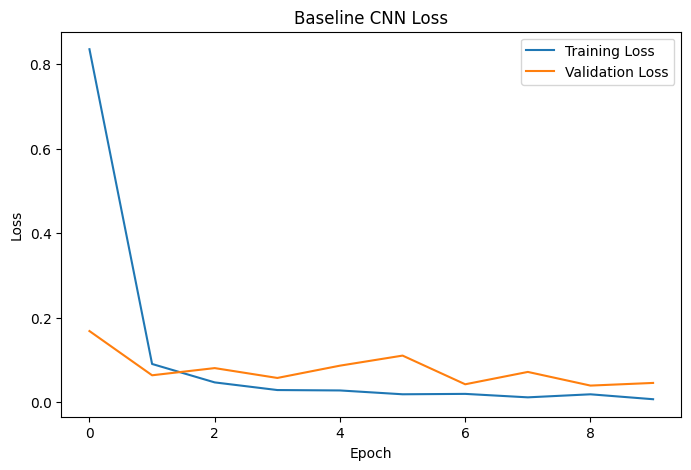

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()
plt.show()

In [32]:
model.save("../models/baseline_cnn_gtsrb.keras")

In [33]:
from pathlib import Path

model_path = Path("../models/baseline_cnn_gtsrb.keras")
print("Model saved:", model_path.exists())

Model saved: True


In [34]:
y_val_pred_probs = model.predict(X_val)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

print("Predictions shape:", y_val_pred.shape)
print("First 10 predictions:", y_val_pred[:10])
print("First 10 true labels:", y_val[:10])

246/246 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
Predictions shape: (7842,)
First 10 predictions: [28  2  1 25 38  9 31 12  1  4]
First 10 true labels: [28  2  1 25 38  9 31 12  1  4]


In [35]:
from sklearn.metrics import classification_report

target_names = [SIGN_LABELS[i] for i in range(43)]

report = classification_report(
    y_val,
    y_val_pred,
    target_names=target_names
)

print(report)

                                              precision    recall  f1-score   support

                        Speed limit (20km/h)       1.00      0.98      0.99        42
                        Speed limit (30km/h)       1.00      0.99      0.99       444
                        Speed limit (50km/h)       0.98      1.00      0.99       450
                        Speed limit (60km/h)       1.00      0.98      0.99       282
                        Speed limit (70km/h)       0.99      0.99      0.99       396
                        Speed limit (80km/h)       0.99      0.98      0.99       372
                 End of speed limit (80km/h)       1.00      0.99      0.99        84
                       Speed limit (100km/h)       0.99      0.99      0.99       288
                       Speed limit (120km/h)       1.00      0.99      0.99       282
                                  No passing       1.00      1.00      1.00       294
       No passing for vehicles over 3.5 tons       1.

In [37]:
!python -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


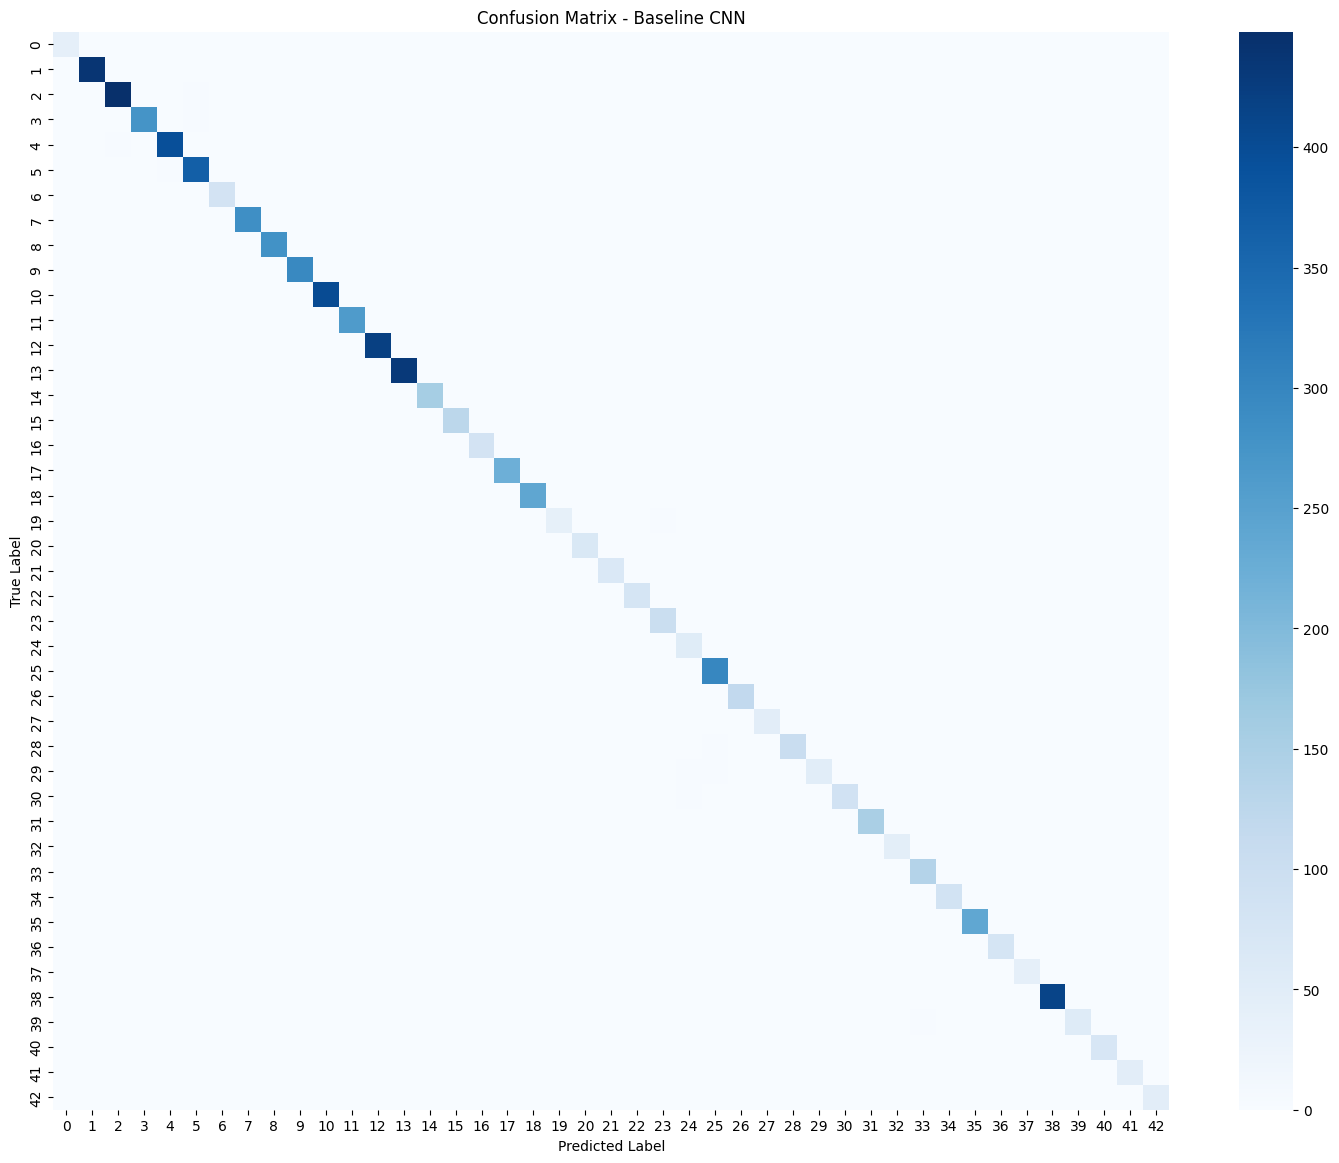

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(18, 14))
sns.heatmap(cm, cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Baseline CNN")
plt.show()

In [39]:
misclassified_indices = np.where(y_val != y_val_pred)[0]

print("Total misclassified images:", len(misclassified_indices))

Total misclassified images: 68


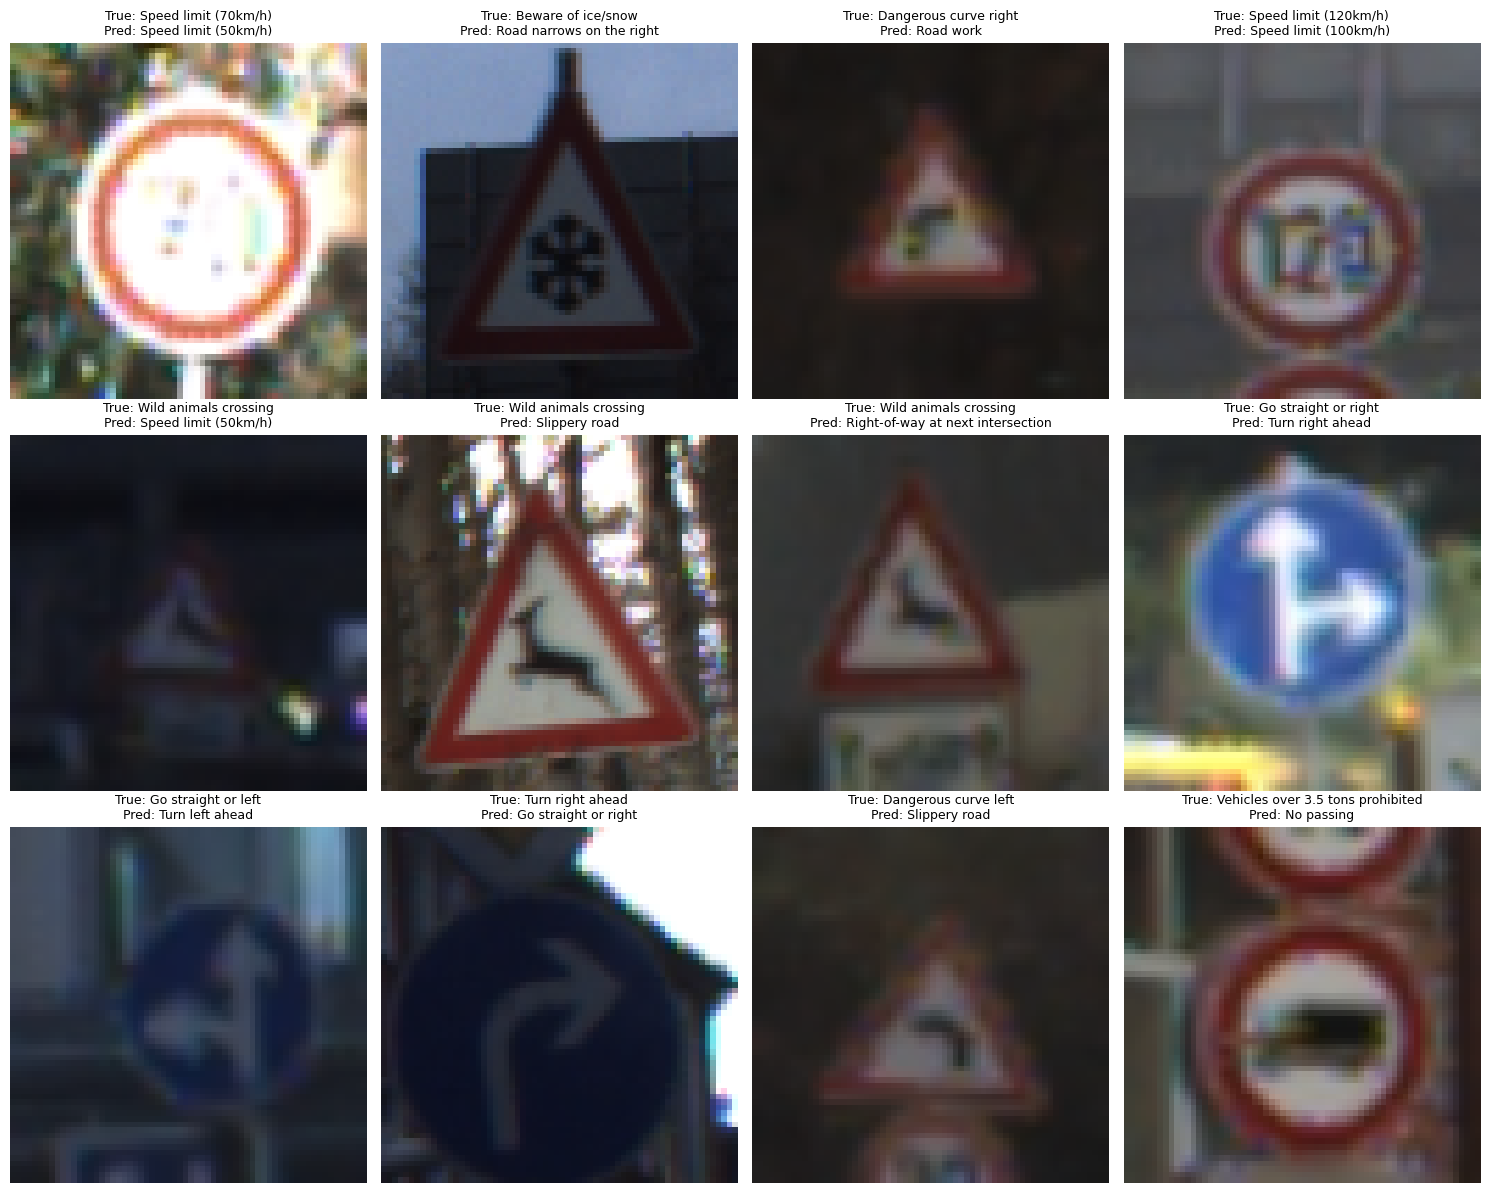

In [40]:
plt.figure(figsize=(15, 12))

for i, idx in enumerate(misclassified_indices[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_val[idx])

    true_label = SIGN_LABELS[y_val[idx]]
    pred_label = SIGN_LABELS[y_val_pred[idx]]

    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [41]:
def load_test_data(test_dir, test_csv, img_size=(64, 64)):
    df = pd.read_csv(test_csv, sep=';')

    images = []
    labels = []

    for _, row in df.iterrows():
        img_path = test_dir / row["Filename"]

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)

        images.append(img)
        labels.append(row["ClassId"])

    return np.array(images), np.array(labels)

In [42]:
X_test, y_test = load_test_data(TEST_DIR, TEST_LABELS)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (12630, 64, 64, 3)
y_test shape: (12630,)


In [43]:
X_test = X_test.astype("float32") / 255.0

print(X_test.min(), X_test.max())

0.0 1.0


In [44]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9629 - loss: 0.2011
Test Loss: 0.20107537508010864
Test Accuracy: 0.9629453420639038


In [45]:
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

print("Predictions shape:", y_test_pred.shape)

395/395 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step
Predictions shape: (12630,)


In [46]:
test_report = classification_report(
    y_test,
    y_test_pred,
    target_names=target_names
)

print(test_report)

                                              precision    recall  f1-score   support

                        Speed limit (20km/h)       1.00      0.87      0.93        60
                        Speed limit (30km/h)       0.94      0.98      0.96       720
                        Speed limit (50km/h)       0.97      0.98      0.98       750
                        Speed limit (60km/h)       0.95      0.95      0.95       450
                        Speed limit (70km/h)       0.98      0.98      0.98       660
                        Speed limit (80km/h)       0.93      0.97      0.95       630
                 End of speed limit (80km/h)       0.99      0.94      0.96       150
                       Speed limit (100km/h)       0.98      0.94      0.96       450
                       Speed limit (120km/h)       0.98      0.94      0.96       450
                                  No passing       0.98      1.00      0.99       480
       No passing for vehicles over 3.5 tons       0.

In [47]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [48]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3]
)

In [49]:
sample_img = X_train[0]
sample_img = np.expand_dims(sample_img, axis=0)

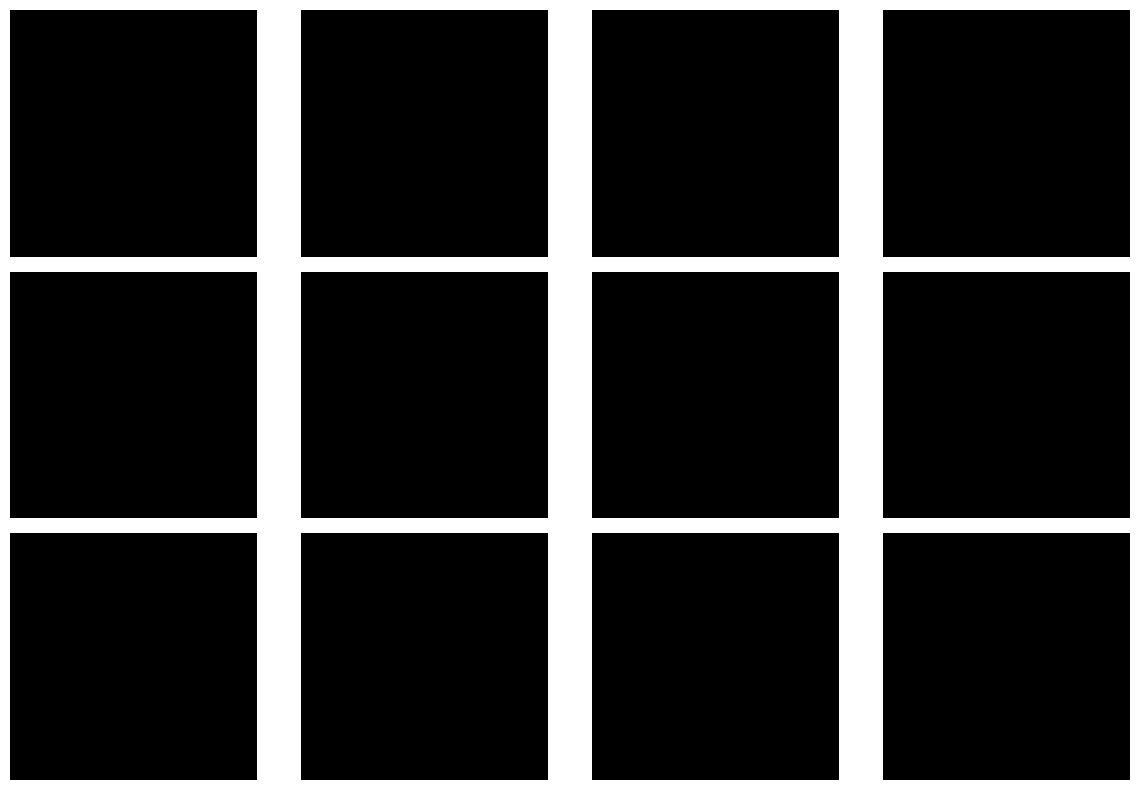

In [50]:
plt.figure(figsize=(12, 8))

i = 0
for batch in datagen.flow(sample_img, batch_size=1):
    plt.subplot(3, 4, i + 1)
    plt.imshow(batch[0])
    plt.axis("off")

    i += 1
    if i == 12:
        break

plt.tight_layout()
plt.show()

In [51]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15
)

In [52]:
sample_img = X_train[0]
sample_img = np.expand_dims(sample_img, axis=0)

In [53]:
print(X_train[0].min(), X_train[0].max())

0.05490196 0.9843137


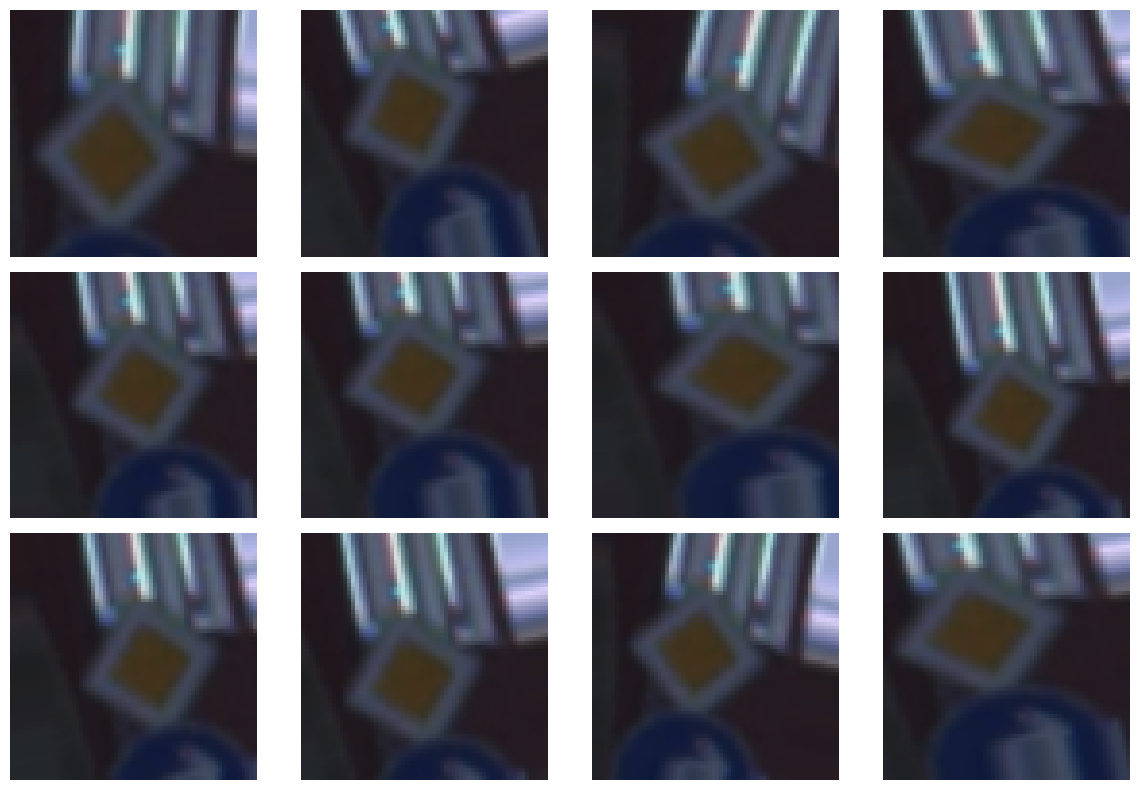

In [54]:
plt.figure(figsize=(12, 8))

i = 0
for batch in datagen.flow(sample_img, batch_size=1):
    plt.subplot(3, 4, i + 1)
    plt.imshow(batch[0])
    plt.axis("off")

    i += 1
    if i == 12:
        break

plt.tight_layout()
plt.show()

In [55]:
test_datagen = ImageDataGenerator(
    brightness_range=[0.8, 1.2]
)

0.0 0.0


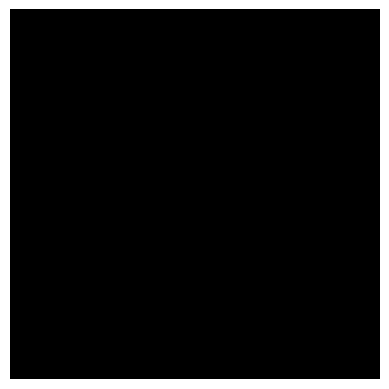

In [56]:
for batch in test_datagen.flow(sample_img, batch_size=1):
    print(batch[0].min(), batch[0].max())
    plt.imshow(batch[0])
    plt.axis("off")
    plt.show()
    break

In [59]:
### Augmentation Debugging Note
'''
Initial brightness augmentation using `brightness_range` produced black images during preview.  
To avoid corrupting training data, brightness augmentation was removed from the current `ImageDataGenerator` pipeline.

Final augmentation used for this phase:
- rotation
- width shift
- height shift
- zoom

Brightness augmentation will be revisited later using a safer TensorFlow-based preprocessing approach.
'''

'\nInitial brightness augmentation using `brightness_range` produced black images during preview.  \nTo avoid corrupting training data, brightness augmentation was removed from the current `ImageDataGenerator` pipeline.\n\nFinal augmentation used for this phase:\n- rotation\n- width shift\n- height shift\n- zoom\n\nBrightness augmentation will be revisited later using a safer TensorFlow-based preprocessing approach.\n'

In [60]:
improved_model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(43, activation="softmax")
])

In [61]:
improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,450,219 (5.53 MB)

 Trainable params: 1,449,259 (5.53 MB)

 Non-trainable params: 960 (3.75 KB)

In [62]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [63]:
history_improved = improved_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 184s 186ms/step - accuracy: 0.3817 - loss: 2.1394 - val_accuracy: 0.7374 - val_loss: 0.8142
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 167s 170ms/step - accuracy: 0.7625 - loss: 0.7243 - val_accuracy: 0.9526 - val_loss: 0.1485
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 168s 171ms/step - accuracy: 0.9081 - loss: 0.3050 - val_accuracy: 0.9693 - val_loss: 0.1010
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 159s 162ms/step - accuracy: 0.9440 - loss: 0.1934 - val_accuracy: 0.9838 - val_loss: 0.0545
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 159s 162ms/step - accuracy: 0.9531 - loss: 0.1675 - val_accuracy: 0.9688 - val_loss: 0.1090
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 159s 163ms/step - accuracy: 0.9657 - loss: 0.1283 - val_accuracy: 0.9872 - val_loss: 0.0405
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 182s 186ms/step - accuracy: 0.9671 - loss: 0.1226 - val_accuracy: 0.9930 - val_loss: 0.0242
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 171s 174ms/step - accuracy: 0.9695 -

In [64]:
improved_model.save("../models/improved_cnn_gtsrb.keras")

In [65]:
test_loss_improved, test_accuracy_improved = improved_model.evaluate(X_test, y_test)

print("Improved Test Loss:", test_loss_improved)
print("Improved Test Accuracy:", test_accuracy_improved)

395/395 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.9803 - loss: 0.1109
Improved Test Loss: 0.11092910170555115
Improved Test Accuracy: 0.9802850484848022


In [66]:
y_test_pred_probs_improved = improved_model.predict(X_test)
y_test_pred_improved = np.argmax(y_test_pred_probs_improved, axis=1)

print(y_test_pred_improved.shape)

395/395 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step
(12630,)


In [67]:
improved_report = classification_report(
    y_test,
    y_test_pred_improved,
    target_names=target_names
)

print(improved_report)

                                              precision    recall  f1-score   support

                        Speed limit (20km/h)       1.00      0.98      0.99        60
                        Speed limit (30km/h)       0.99      1.00      1.00       720
                        Speed limit (50km/h)       0.99      0.99      0.99       750
                        Speed limit (60km/h)       1.00      0.98      0.99       450
                        Speed limit (70km/h)       0.98      0.99      0.99       660
                        Speed limit (80km/h)       0.98      0.98      0.98       630
                 End of speed limit (80km/h)       1.00      0.89      0.94       150
                       Speed limit (100km/h)       1.00      0.98      0.99       450
                       Speed limit (120km/h)       0.99      0.98      0.98       450
                                  No passing       0.98      1.00      0.99       480
       No passing for vehicles over 3.5 tons       1.

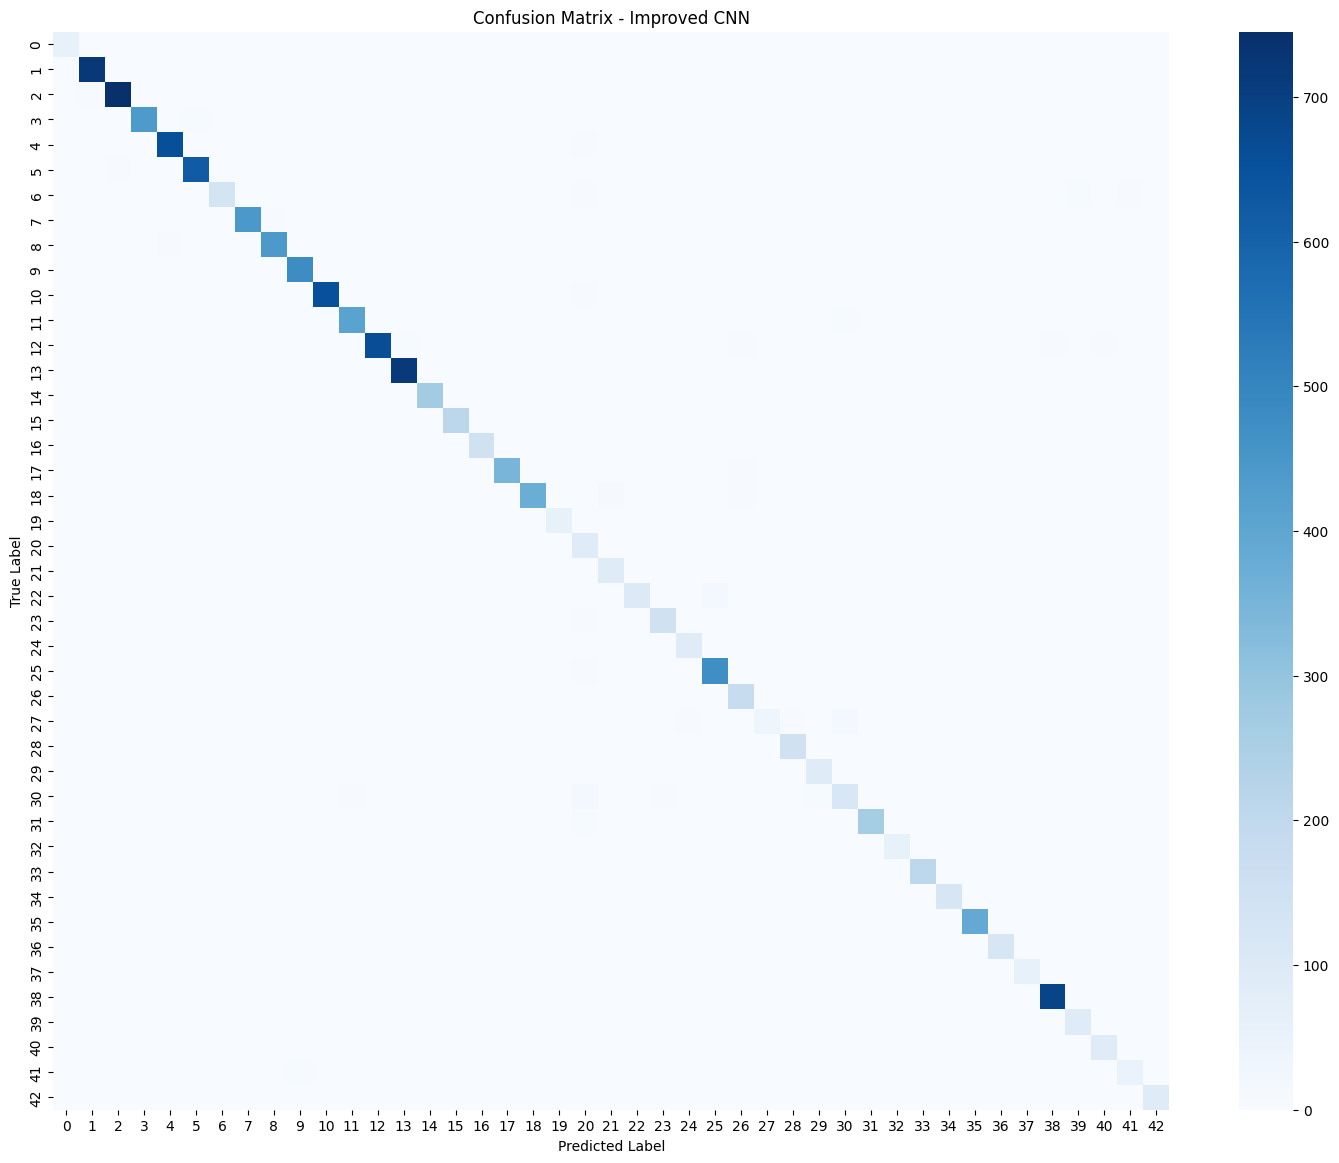

In [68]:
cm_improved = confusion_matrix(y_test, y_test_pred_improved)

plt.figure(figsize=(18, 14))
sns.heatmap(cm_improved, cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Improved CNN")

plt.show()

In [69]:
misclassified_improved = np.where(y_test != y_test_pred_improved)[0]

print("Total misclassified images:", len(misclassified_improved))

Total misclassified images: 249


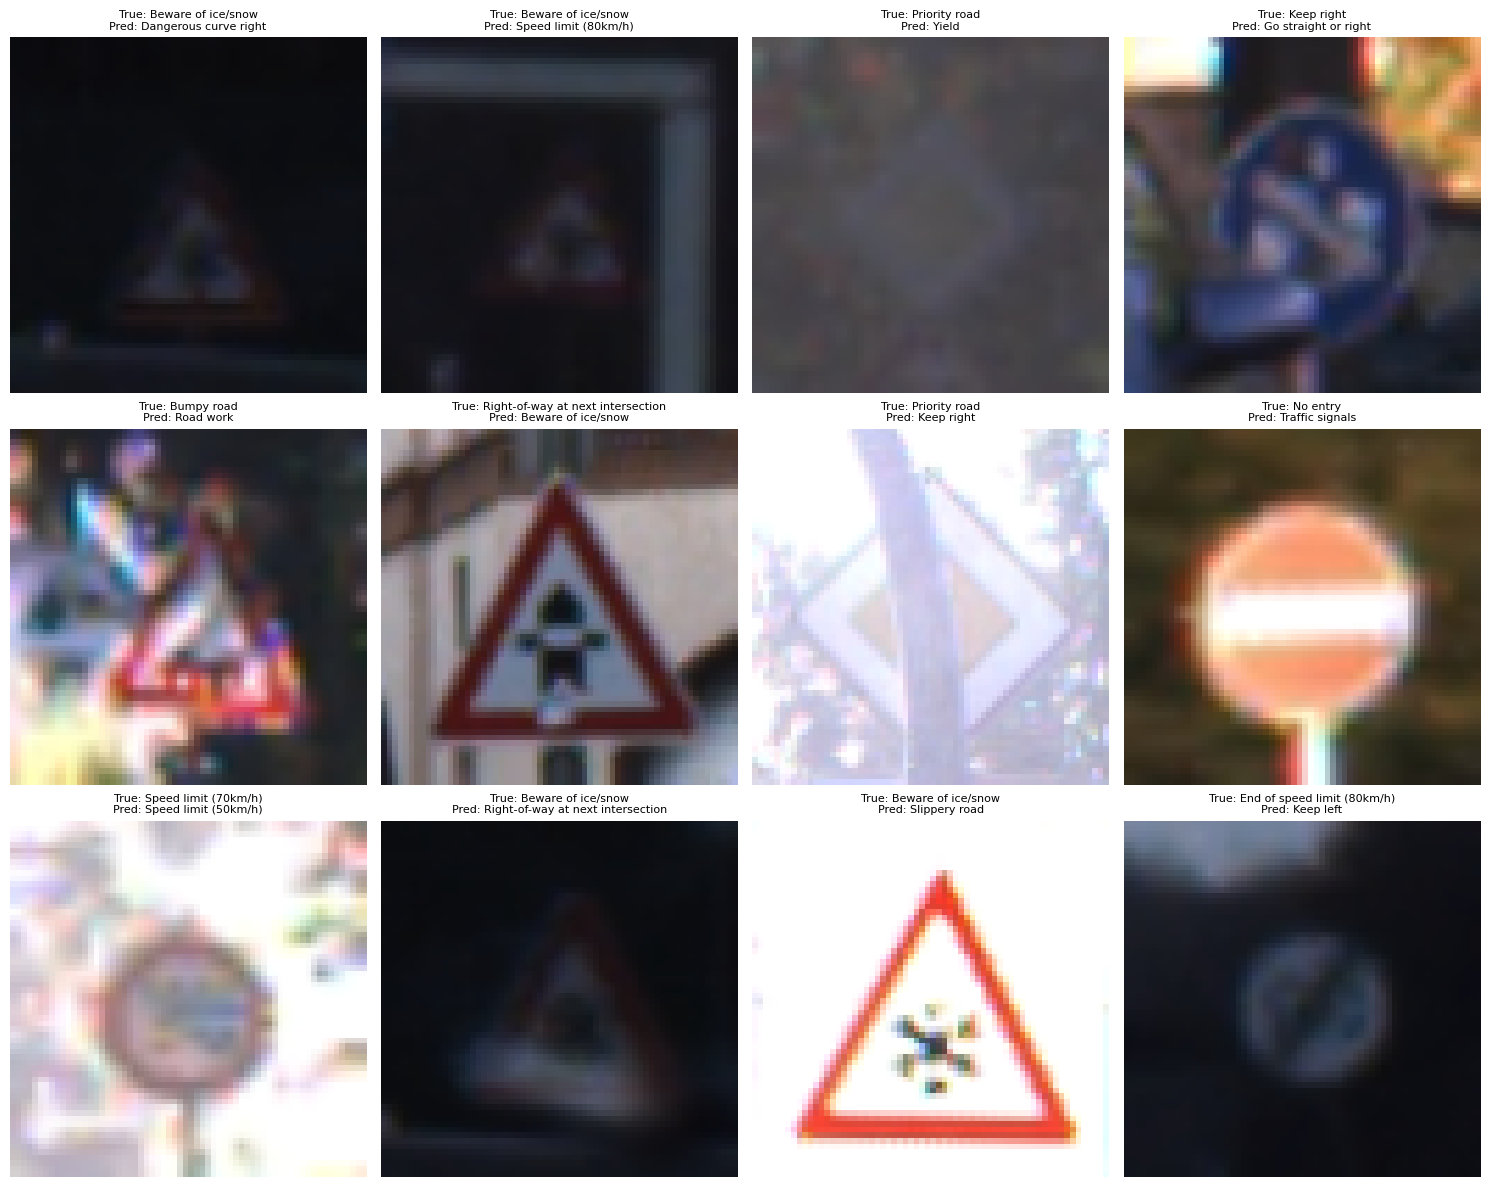

In [70]:
plt.figure(figsize=(15, 12))

for i, idx in enumerate(misclassified_improved[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[idx])

    true_label = SIGN_LABELS[y_test[idx]]
    pred_label = SIGN_LABELS[y_test_pred_improved[idx]]

    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [71]:
for layer in improved_model.layers:
    print(layer.name, layer.__class__.__name__)

conv2d_6 Conv2D
batch_normalization BatchNormalization
max_pooling2d_6 MaxPooling2D
conv2d_7 Conv2D
batch_normalization_1 BatchNormalization
max_pooling2d_7 MaxPooling2D
conv2d_8 Conv2D
batch_normalization_2 BatchNormalization
max_pooling2d_8 MaxPooling2D
conv2d_9 Conv2D
batch_normalization_3 BatchNormalization
max_pooling2d_9 MaxPooling2D
flatten_2 Flatten
dense_4 Dense
dropout Dropout
dense_5 Dense


In [72]:
last_conv_layer_name = "conv2d_9"

In [75]:
_ = improved_model(tf.zeros((1, 64, 64, 3)))

In [76]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    max_value = tf.reduce_max(heatmap)
    if max_value == 0:
        return heatmap.numpy()

    heatmap = tf.maximum(heatmap, 0) / max_value

    return heatmap.numpy()

/opt/anaconda3/envs/traffic-sign-ai/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_20']
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)


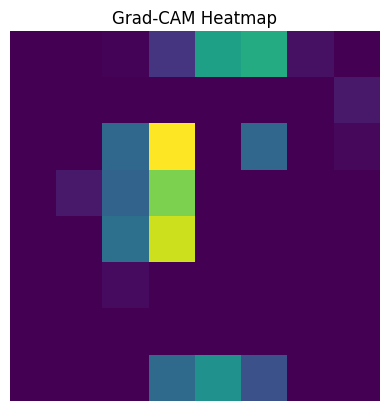

In [77]:
idx = 0

img = X_test[idx]
img_array = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(
    img_array,
    improved_model,
    last_conv_layer_name
)

plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

In [78]:
import matplotlib.cm as cm

def display_gradcam(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_uint8]

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

    plt.show()

/var/folders/v1/506ywqvd63g2qdf8vnln0_s80000gn/T/ipykernel_76687/4109107853.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


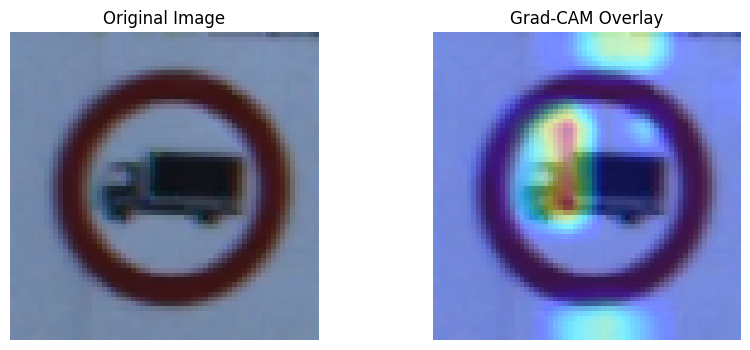

In [79]:
display_gradcam(img, heatmap)

True label: Beware of ice/snow
Predicted label: Dangerous curve right


/var/folders/v1/506ywqvd63g2qdf8vnln0_s80000gn/T/ipykernel_76687/4109107853.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


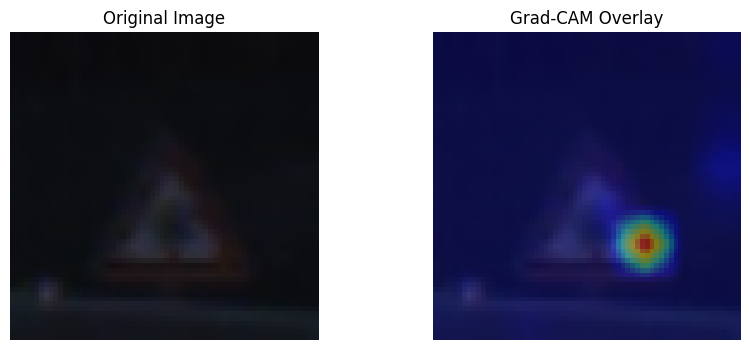

In [80]:
idx = misclassified_improved[0]

img = X_test[idx]
img_array = np.expand_dims(img, axis=0)

true_label = SIGN_LABELS[y_test[idx]]
pred_label = SIGN_LABELS[y_test_pred_improved[idx]]

print("True label:", true_label)
print("Predicted label:", pred_label)

heatmap = make_gradcam_heatmap(
    img_array,
    improved_model,
    last_conv_layer_name
)

display_gradcam(img, heatmap)

In [81]:
# Find correctly classified triangular warning-sign examples
triangle_class_ids = list(range(18, 32))  # warning sign classes

correct_triangle_indices = np.where(
    (y_test == y_test_pred_improved) &
    (np.isin(y_test, triangle_class_ids))
)[0]

print("Correct triangular warning examples:", len(correct_triangle_indices))

Correct triangular warning examples: 2256


True label: General caution
Predicted label: General caution


/var/folders/v1/506ywqvd63g2qdf8vnln0_s80000gn/T/ipykernel_76687/4109107853.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


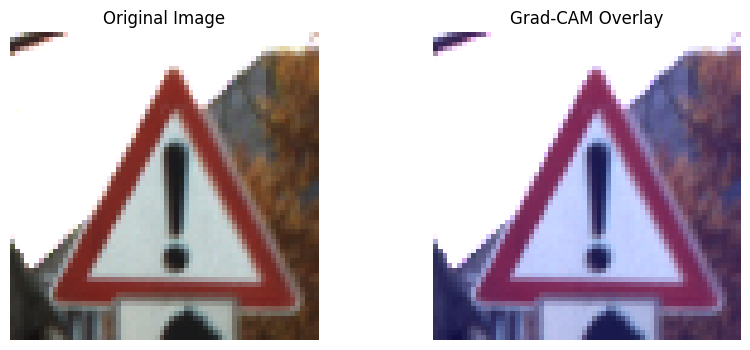

In [82]:
idx = correct_triangle_indices[0]

img = X_test[idx]
img_array = np.expand_dims(img, axis=0)

true_label = SIGN_LABELS[y_test[idx]]
pred_label = SIGN_LABELS[y_test_pred_improved[idx]]

print("True label:", true_label)
print("Predicted label:", pred_label)

heatmap = make_gradcam_heatmap(
    img_array,
    improved_model,
    last_conv_layer_name
)

display_gradcam(img, heatmap)